# Ejercicio 1 - Velocidades del viento

En esta seccion, desarrollaremos el EDA y ETL de la base de datos de **"Velocidades de viento"** con el fin de comprender y analizar la problematica planteada.

A continuacion, instalaremos las librerias quer seran utilizadas a lo largo del ejercicio.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#### EDA y ETL 

In [29]:
df = pd.read_csv('/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/Parcial1ML/docs/data_treino_dv_df_2000_2010.csv')
df

,HORA (UTC),"VENTO, DIREï¿½ï¿½O HORARIA (gr) (ï¿½ (gr))","VENTO, VELOCIDADE HORARIA (m/s)",UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),TEMPERATURA Mï¿½XIMA NA HORA ANT. (AUT) (ï¿½C),TEMPERATURA Mï¿½NIMA NA HORA ANT. (AUT) (ï¿½C),"UMIDADE RELATIVA DO AR, HORARIA (%)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)","PRECIPITAï¿½ï¿½O TOTAL, HORï¿½RIO (mm)","VENTO, RAJADA MAXIMA (m/s)",PRESSï¿½O ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSï¿½O ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)
0,12:00,0.809017,1.8,69.0,60.0,22.6,20.7,61.0,888.2,0.0,3.8,888.2,887.7
1,13:00,0.965926,2.7,62.0,55.0,24.2,22.5,55.0,888.4,0.0,4.7,888.4,888.2
2,14:00,0.891007,2.0,56.0,50.0,25.5,24.3,51.0,888.1,0.0,4.9,888.4,888.1
3,15:00,0.848048,2.5,52.0,44.0,27.4,25.0,44.0,887.4,0.0,5.8,888.1,887.4
4,16:00,0.224951,2.4,50.0,43.0,27.1,25.5,46.0,886.5,0.0,5.8,887.4,886.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87688,19:00,-0.615661,5.6,83.0,78.0,21.8,21.1,80.0,879.1,0.0,12.3,879.8,879.1
87689,20:00,-0.469472,4.9,84.0,79.0,21.7,21.0,84.0,879.2,0.0,9.9,879.2,878.9
87690,21:00,-0.484810,4.5,86.0,82.0,21.2,20.6,86.0,879.7,0.0,8.9,879.8,879.2
87691,22:00,-0.484810,3.2,88.0,85.0,20.6,20.2,88.0,880.5,0.0,8.0,880.5,879.6


Observamos 87693 muestras y 13 columnas de las cuales...

#### Renombramiento de columnas

A continuación se muestra la correspondencia entre los nombres originales del dataset y los nuevos nombres utilizados para facilitar el análisis:

| Nombre original                                                      | Nuevo nombre         |
|----------------------------------------------------------------------|----------------------|
| HORA (UTC)                                                           | `hora`               |
| VENTO, DIREÇÃO HORARIA (gr)                                          | `viento_dir`         |
| VENTO, VELOCIDADE HORARIA (m/s)                                      | `viento_vel`         |
| UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)                             | `humedad_max_ant`    |
| UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)                             | `humedad_min_ant`    |
| TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)                           | `temp_max_ant`       |
| TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)                           | `temp_min_ant`       |
| UMIDADE RELATIVA DO AR, HORARIA (%)                                  | `humedad_horaria`    |
| PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)               | `presion_horaria`    |
| PRECIPITAÇÃO TOTAL, HORÁRIA (mm)                                     | `precipitacion`      |
| VENTO, RAJADA MAXIMA (m/s)                                           | `viento_rafaga_max`  |
| PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)                      | `presion_max_ant`    |
| PRESSÃO ATMOSFERICA MIN.NA HORA ANT. (AUT) (mB)                      | `presion_min_ant`    |


In [30]:
# Renombramos los nombres de cada columna 
df.columns = [
    'hora',
    'viento_dir',
    'viento_vel',
    'humedad_max_ant',
    'humedad_min_ant',
    'temp_max_ant',
    'temp_min_ant',
    'humedad_horaria',
    'presion_horaria',
    'precipitacion',
    'viento_rafaga_max',
    'presion_max_ant',
    'presion_min_ant'
    ]

df.columns

Index(['hora', 'viento_dir', 'viento_vel', 'humedad_max_ant',
       'humedad_min_ant', 'temp_max_ant', 'temp_min_ant', 'humedad_horaria',
       'presion_horaria', 'precipitacion', 'viento_rafaga_max',
       'presion_max_ant', 'presion_min_ant'],
      dtype='object')

Empezaremos con el analisis de las variables...

#### Descripcion de tipos de variables

In [5]:
var = [
    'hora',
    'viento_dir',
    'viento_vel',
    'humedad_max_ant',
    'humedad_min_ant',
    'temp_max_ant',
    'temp_min_ant',
    'humedad_horaria',
    'presion_horaria',
    'precipitacion',
    'viento_rafaga_max',
    'presion_max_ant',
    'presion_min_ant'
    ]

df[var].describe().T

,count,mean,std,min,25%,50%,75%,max
viento_dir,87693.0,0.405810,0.686247,-1.0,-0.156434,0.788011,0.970296,1.0
viento_vel,87693.0,2.466192,1.313968,0.0,1.500000,2.400000,3.400000,10.0
humedad_max_ant,87693.0,69.058465,19.640222,12.0,54.000000,72.000000,87.000000,100.0
humedad_min_ant,87693.0,63.176194,20.166336,10.0,48.000000,64.000000,80.000000,98.0
temp_max_ant,87693.0,21.921264,3.721386,9.2,19.200000,21.400000,24.700000,35.3
temp_min_ant,87693.0,20.684570,3.513744,8.4,18.400000,20.200000,23.100000,34.4
humedad_horaria,87693.0,66.146682,19.992327,10.0,51.000000,68.000000,84.000000,99.0
presion_horaria,87693.0,887.251925,4.012404,863.4,885.300000,887.200000,889.100000,1023.5
precipitacion,87693.0,0.160907,1.307515,0.0,0.000000,0.000000,0.000000,70.8
viento_rafaga_max,87693.0,5.161076,2.311157,0.0,3.400000,5.000000,6.800000,24.3


Observamos en la tabla anterior que...

In [6]:
df.isnull().sum()

hora                 0
viento_dir           0
viento_vel           0
humedad_max_ant      0
humedad_min_ant      0
temp_max_ant         0
temp_min_ant         0
humedad_horaria      0
presion_horaria      0
precipitacion        0
viento_rafaga_max    0
presion_max_ant      0
presion_min_ant      0
dtype: int64

Observamos que no existen datos faltantes a lo largo del dataframe, por lo que no es necesario realizar un preprocesamiento de datos. 

A continuacion...

#### Analisis de correlacion entre variables explicativas y de respuesta

En esta seccion, analizaremos la correlacion entre las variables independientes (X) y la variable dependiente (y).

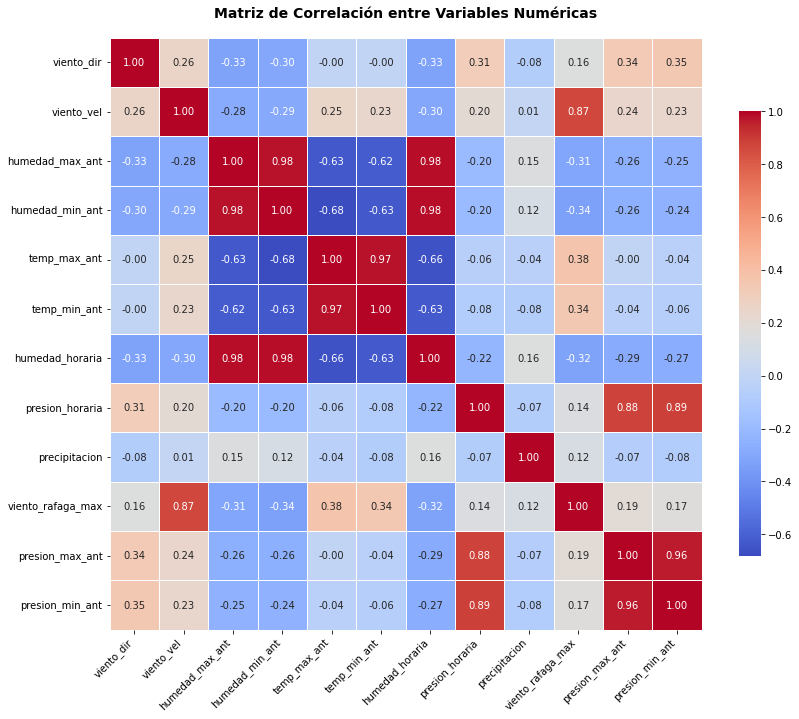

In [61]:
# Calcular la correlación
corr_matrix = df.corr()

# Crear figura más grande
plt.figure(figsize=(12, 10))

# Dibujar heatmap
sns.heatmap(
    corr_matrix,
    annot=True,                 # Mostrar los valores
    fmt=".2f",                  # Formato de los números
    cmap='coolwarm',            # Mapa de color
    square=True,                # Cuadrícula cuadrada
    cbar_kws={"shrink": 0.75},  # Barra de color más pequeña
    linewidths=0.5,             # Líneas entre celdas
    annot_kws={"size": 10}      # Tamaño del texto de los valores
)

# Ajustes de etiquetas
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Título general
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

en la figura anterior, observamos...

In [62]:
df.corr()['viento_vel'].sort_values(ascending=False)

viento_vel           1.000000
viento_rafaga_max    0.868279
viento_dir           0.256588
temp_max_ant         0.247706
presion_max_ant      0.242446
presion_min_ant      0.231584
temp_min_ant         0.231472
presion_horaria      0.204031
precipitacion        0.009466
humedad_max_ant     -0.282787
humedad_min_ant     -0.291752
humedad_horaria     -0.301358
Name: viento_vel, dtype: float64

Se evidencia una correlación significativa entre la variable de respuesta *"viento_vel"* y diversas variables independientes del conjunto de datos. Para el análisis y desarrollo de los modelos de predicción, se seleccionarán las variables "**vel_rafaga_max**", "**humedad_horaria**", "**presion_max_ant**" y "**temp_max_ant**", ya que presentan los niveles más altos de correlación con la variable objetivo.

Esta selección no solo responde a su fuerza de correlación, sino también a su capacidad para representar otras variables pertenecientes a sus respectivas categorías. Es decir, variables como presión, temperatura, humedad y viento cuentan con múltiples subcategorías que derivan de una misma fuente de medición. Por esta razón, las variables seleccionadas actúan como representativas de su grupo, y las altas correlaciones observadas entre subcategorías se explican por el hecho de provenir de una misma categoría física.

Analizaremos la variable de respuesta con respecto a las variables seleccionadas.

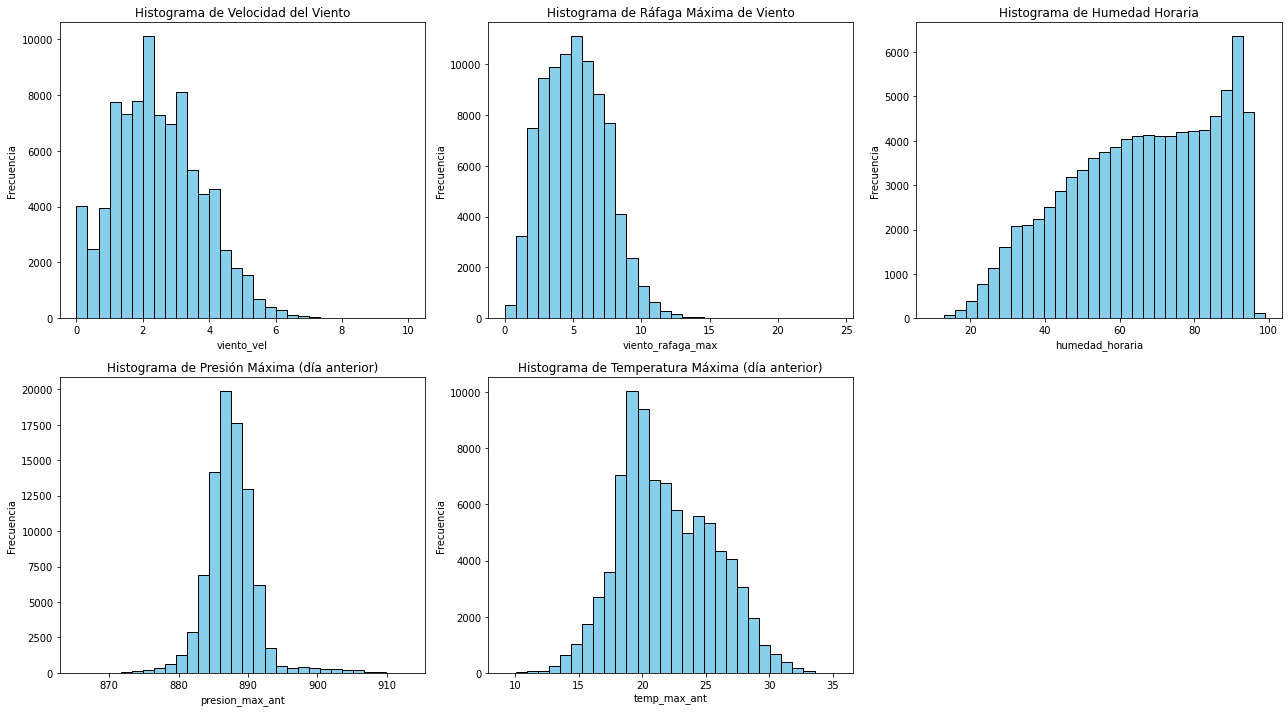

In [63]:
# Variables a graficar
variables = ['viento_vel', 'viento_rafaga_max', 'humedad_horaria', 'presion_max_ant', 'temp_max_ant']
titulos = [
    'Velocidad del Viento',
    'Ráfaga Máxima de Viento',
    'Humedad Horaria',
    'Presión Máxima (día anterior)',
    'Temperatura Máxima (día anterior)'
]

# Crear figura con subplots (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Tamaño ajustado

# Aplanamos los ejes para facilitar el indexado
axes = axes.flatten()

# Graficar cada variable
for i, var in enumerate(variables):
    axes[i].hist(df[var], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {titulos[i]}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

# Eliminar el subplot vacío (último en posición 6 si solo usamos 5)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

En la figura anterior, podemos observar la distribucion de frecuencia de cada una de las variables explikcativas y variable de respuesta. Se evidencia...

#### Analisis de simetria y datos atipicos 

En esta seccion...

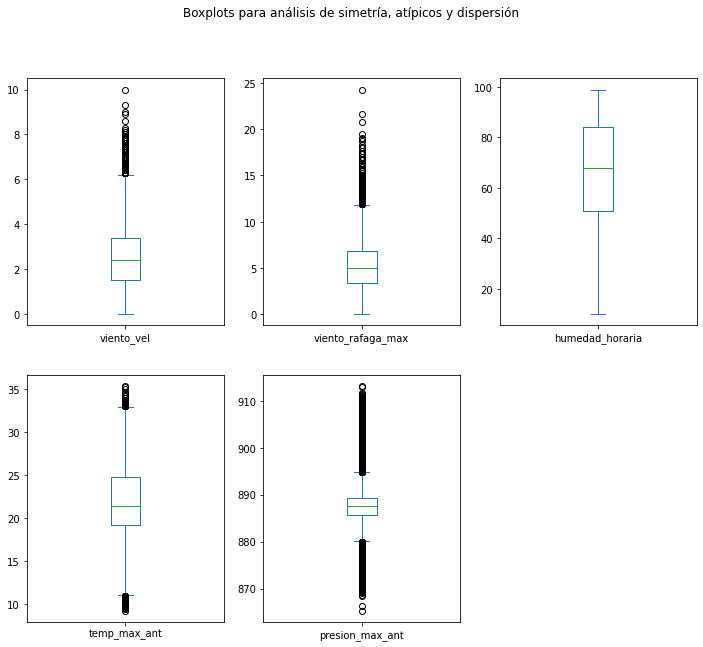

In [ ]:
df[variables].plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 10), sharex=False)
plt.suptitle('Boxplots para análisis de simetría, atípicos y dispersión')
plt.show()

Observamos que...

In [40]:
df[variables].skew()

viento_vel           0.370276
viento_rafaga_max    0.411720
humedad_horaria     -0.349514
temp_max_ant         0.263013
presion_max_ant      1.024888
dtype: float64

Observamos que...

#### Analisis bivariado

aqui realizaremos...

<AxesSubplot:title={'center':'Velocidad promedio del viento por hora'}, xlabel='hora'>

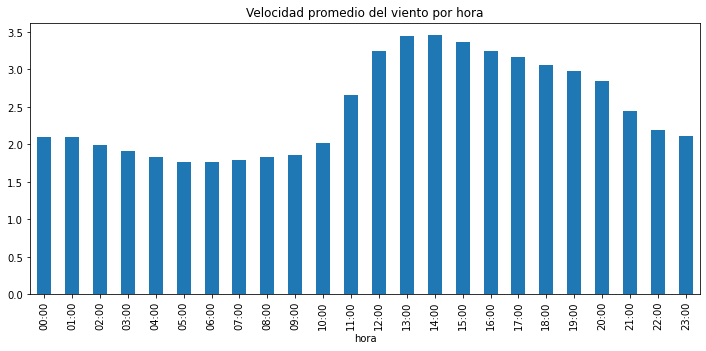

In [60]:
df.groupby('hora')['viento_vel'].mean().sort_index().plot(kind='bar', figsize=(12, 5), title='Velocidad promedio del viento por hora')